In [32]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# DATOS

In [33]:
acciones = ["GGAL", "YPF", "BMA", "CEPU","PAM"]
indice = "^GSPC"
start = "2021-01-01"
end = "2024-12-31"
pesos = np.array([0.25,0.2,0.2,0.2,0.15]) #debe sumar 1

datos = yf.download (acciones + [indice], start=start, end=end)["Close"]
datos.dropna(inplace=True)

retornos = np.log(datos/datos.shift(1)).dropna()

retorno_cartera = retornos[acciones] @ pesos #ponderacion
retorno_indice = retornos[indice]

[*********************100%***********************]  6 of 6 completed


In [34]:
df = pd.DataFrame({"cartera": retorno_cartera,"indice": retorno_indice})
df

,cartera,indice
Date,,
2021-01-05,-0.003244,0.007058
2021-01-06,0.003239,0.005694
2021-01-07,0.006920,0.014738
2021-01-08,-0.014442,0.005477
2021-01-11,-0.037958,-0.006576
...,...,...
2024-12-23,0.008309,0.007261
2024-12-24,0.021030,0.010982
2024-12-26,0.004221,-0.000406


# Betas, hedge ratio y contratos

In [35]:
slope, intercept, r_value, p_value, std_error = stats.linregress(df["indice"], df["cartera"])
beta_estatico = slope
print(f"Beta estático: {beta_estatico:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Standard error: {std_error:.4f}")
print(f"R²: {r_value**2:.4f}")

Beta estático: 0.9789
p-value: 0.0000
Standard error: 0.0798
R²: 0.1307


El R² de 0.13 refleja que el principal driver de riesgo de una cartera de acciones argentinas no es el mercado americano sino el riesgo país. Una cobertura óptima requeriría instrumentos indexados al riesgo soberano argentino (CDS, futuros de tipo de cambio) o usar el Merval como índice de referencia aceptando las distorsiones inflacionarias.

Replica cercanamente al mercado/indice (~1)

In [36]:
VC = 1_000_000  #cartera (USD)
Vf = datos[indice].iloc[-1]  #futuro (simplificado para el proyecto)
Q = 50  #multiplicador indice (E-mini S&P500 (USD por punto) = 50)

Nf = -beta_estatico*(VC/(Vf*Q))
print(f"Numero de contratos de futuro: {round(Nf,2)}\nRedondeado: {round(Nf)}")

Numero de contratos de futuro: -3.31
Redondeado: -3


# Rolling betas

In [ ]:
ventana = 60 #dias habiles ~ 3 meses
def rolling_beta(ret_cartera,ret_indice,ventana):
    betas = []
    fechas = []
    for i in range (ventana, len(ret_cartera)):
        x = ret_indice.iloc[i-ventana:i]
        y = ret_cartera.iloc[i-ventana:i]
        b,_,_,_,_ = stats.linregress(x,y)
        betas.append(b)
        fechas.append(ret_cartera.index[i])
    return pd.Series(betas,index=fechas,name="beta_rolling")

Vf_historico = datos[indice]

beta_rolling = rolling_beta(df['cartera'], df['indice'], ventana)
Nroll = beta_rolling*VC/(Vf_historico*Q) #distintos contratos a ejecutra en distintos momentos
Nroll.dropna() #no hace falta ventana para el Vf_historico, dropna() los ajusta a los valores de beta

2021-04-01    5.240650
2021-04-05    5.173991
2021-04-06    4.983919
2021-04-07    4.982384
2021-04-08    5.020692
                ...   
2024-12-23    4.563932
2024-12-24    4.467208
2024-12-26    4.584148
2024-12-27    4.889690
2024-12-30    4.863259
Length: 943, dtype: float64

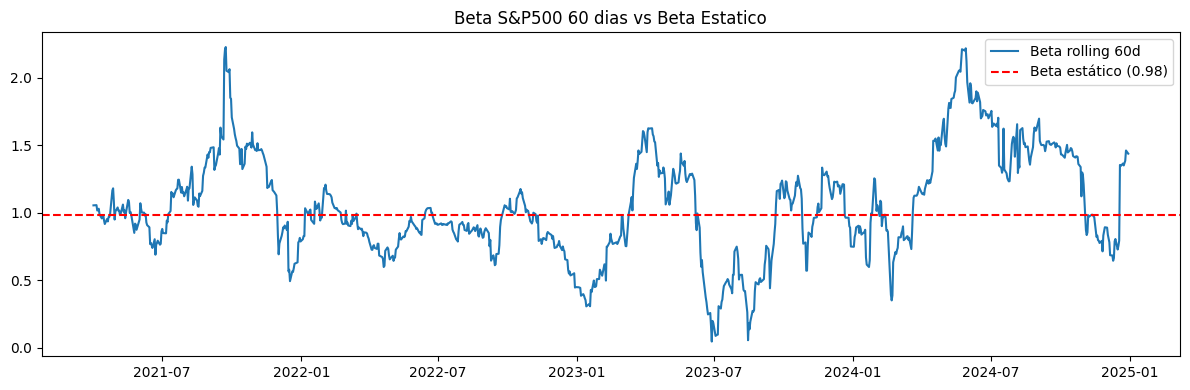

In [38]:
plt.figure(figsize = (12,4))
plt.plot(beta_rolling,label='Beta rolling 60d')
plt.axhline(beta_estatico, color = "red", linestyle = "--", label=f'Beta estático ({beta_estatico:.2f})')
plt.title ("Beta S&P500 60 dias vs Beta Estatico")
plt.legend()
plt.tight_layout()


# Simulacion de beta objetivo

In [39]:

def contratos_beta_objetivo(beta_obj, beta_actual, VC, Vf, Q):
    N = (beta_obj - beta_actual) * VC / (Vf * Q)
    return N

escenarios = {
    'Cobertura total (B=0)': 0.0,
    'Reducción parcial (B=0.5)': 0.5,
    'Sin cambio (B=actual)': beta_estatico,
    'Aumento exposición (B=1.5)': 1.5,
}

for nombre, beta_obj in escenarios.items():
    N = contratos_beta_objetivo (beta_obj, beta_estatico, VC, Vf, Q)
    accion = "vender" if N < 0 else "comprar"
    print(f"{nombre}: {accion} {abs(N):.2f} contratos")

Cobertura total (B=0): vender 3.31 contratos
Reducción parcial (B=0.5): vender 1.62 contratos
Sin cambio (B=actual): comprar 0.00 contratos
Aumento exposición (B=1.5): comprar 1.76 contratos


# Backtesting

In [40]:
df_bt = df.copy()
df_bt["beta_rolling"] = beta_rolling
df_bt.dropna(inplace=True)


df_bt["sin_cobertura"] = df_bt["cartera"]
df_bt["futuro"] = -df_bt['beta_rolling'] * df_bt['indice']
df_bt["cubierto"] = df_bt['sin_cobertura'] + df_bt['futuro']

df_bt

,cartera,indice,beta_rolling,sin_cobertura,futuro,cubierto
Date,,,,,,
2021-04-01,0.006278,0.011756,1.053337,0.006278,-0.012383,-0.006105
2021-04-05,-0.005777,0.014335,1.054953,-0.005777,-0.015123,-0.020900
2021-04-06,0.027791,-0.000974,1.015209,0.027791,0.000989,0.028780
2021-04-07,-0.022926,0.001474,1.016394,-0.022926,-0.001498,-0.024425
2021-04-08,-0.001560,0.004212,1.028531,-0.001560,-0.004332,-0.005892
...,...,...,...,...,...,...
2024-12-23,0.008309,0.007261,1.363262,0.008309,-0.009898,-0.001590
2024-12-24,0.021030,0.010982,1.349106,0.021030,-0.014816,0.006214
2024-12-26,0.004221,-0.000406,1.383860,0.004221,0.000561,0.004783


El beta estático sobre todo el período es 0.98, pero el rolling termina en valores de 1.36–1.46 en 2024 (las acciones argentinas se correlacionaron más fuertemente con el mercado global al reducirse el riesgo país. El beta subió estructuralmente en ese período)

In [41]:
def metricas (retornos, nombre):
    ret_acum = (1+retornos).cumprod()
    vol_anual = retornos.std() * np.sqrt(252)
    sharpe = (retornos.mean() * 252) / vol_anual
    max_dd = (ret_acum / ret_acum.cummax() - 1).min()
    print(f"{nombre}")
    print(f"  Retorno acumulado: {ret_acum.iloc[-1]-1:.2%}")
    print(f"  Volatilidad anual: {vol_anual:.2%}")
    print(f"  Sharpe ratio:      {sharpe:.2f}")
    print(f"  Max drawdown:      {max_dd:.2%}")   
metricas(df_bt['sin_cobertura'], 'Cartera sin cubrir')
metricas(df_bt['cubierto'], 'Cartera cubierta') 

Cartera sin cubrir
  Retorno acumulado: 504.02%
  Volatilidad anual: 45.17%
  Sharpe ratio:      1.29
  Max drawdown:      -40.18%
Cartera cubierta
  Retorno acumulado: 281.06%
  Volatilidad anual: 42.55%
  Sharpe ratio:      1.05
  Max drawdown:      -34.13%


La poca diferencia en volatilidad es explicada por el R2

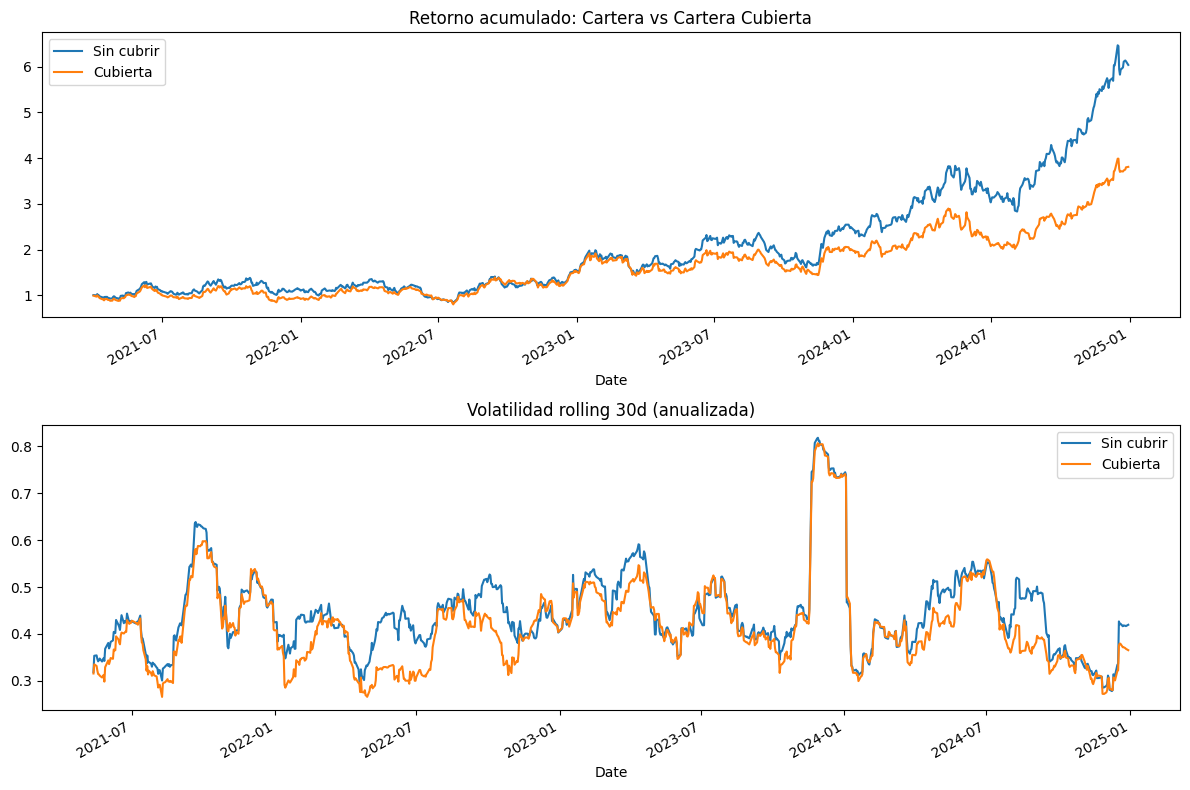

In [42]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Retornos acumulados
(1 + df_bt[['sin_cobertura', 'cubierto']]).cumprod().plot(
    ax=axes[0], title='Retorno acumulado: Cartera vs Cartera Cubierta'
)
axes[0].legend(['Sin cubrir', 'Cubierta'])

# Volatilidad rolling
df_bt['vol_sin_cubrir'] = df_bt['sin_cobertura'].rolling(30).std() * np.sqrt(252)
df_bt['vol_cubierta'] = df_bt['cubierto'].rolling(30).std() * np.sqrt(252)
df_bt[['vol_sin_cubrir', 'vol_cubierta']].plot(
    ax=axes[1], title='Volatilidad rolling 30d (anualizada)'
)
axes[1].legend(['Sin cubrir', 'Cubierta'])

plt.tight_layout()
plt.show()

# Datos Excel

In [43]:
parametros = {"Valor Cartera": VC,
             "Valor Indice": Q,
             "Ventana": ventana,
             "Fecha Inicio": start,
             "Fecha Final": end,
             "Acciones": acciones,
             "Ponderaciones": pesos,
             "Beta Estatico": beta_estatico,
             "Valor del Futuro": Vf, 
             "Cantidad de contratos": Nf
}
parametrosdf = pd.DataFrame(parametros)
parametrosdf.to_excel("parametros.xlsx", index=False)